Mejorar calidad de las imagenes

[aptos] nivel 3 -> 3435fd8675a2.png


C:\Users\drive\AppData\Local\Temp\ipykernel_1332\3307586247.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  muV, sdV = float(muV), float(sdV)


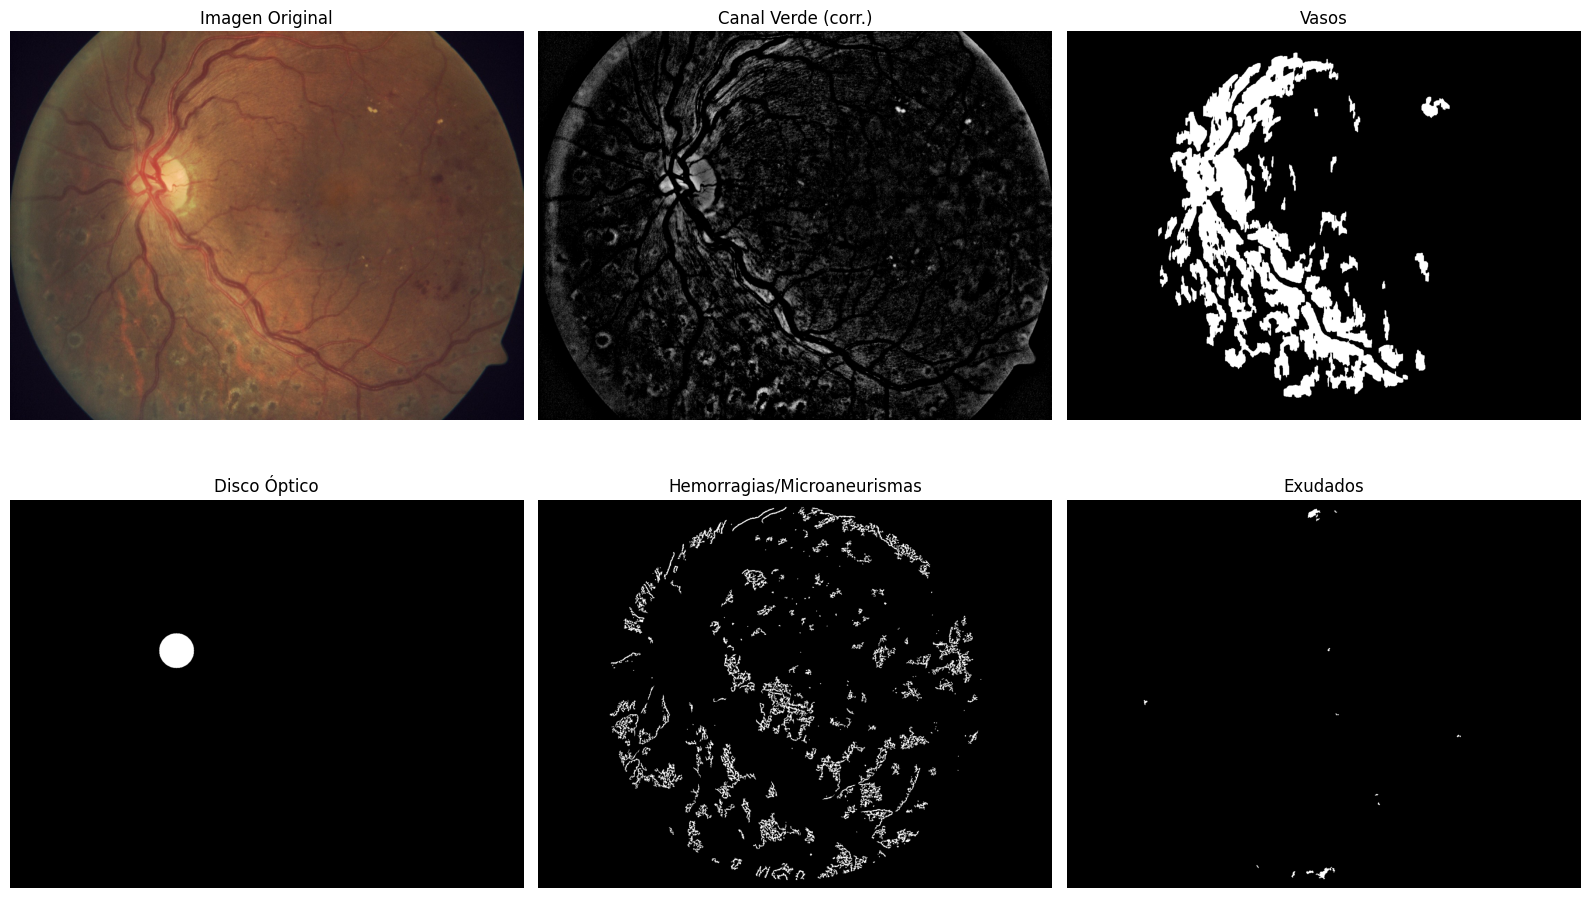

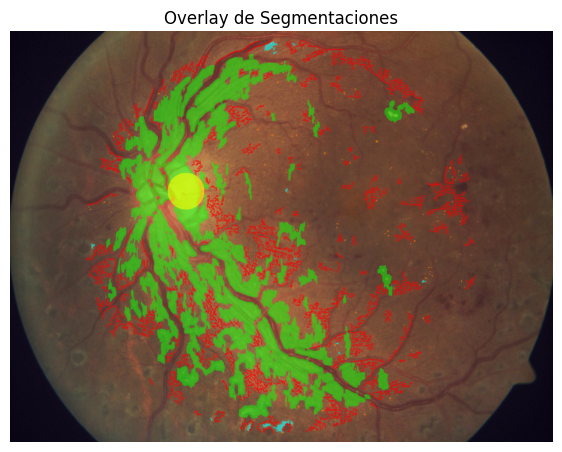

In [ ]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, pandas as pd

DATASETS = {
    "aptos": {
        "img_dir": r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train",
        "csv":     r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train.csv",
        "exts":    (".jpeg", ".jpg", ".png"),
        "preset": {
            "remove_scars": True,   
            "ring_exclude": True,

            # Vasos
            "vessels_zsigma": 1.25,
            "vessels_min_area": 150,
            "vessels_min_elong": 3.2,
            "vessels_ecc_min": 6.0,           
            "vessels_keep_if_area": 1200,     
            "vessels_round_cut_area": 900,
            "vessel_excl_thin": 5,

            # Lesiones oscuras
            "vessel_excl_dilate": 15,
            "od_excl_dilate": 24,
            "contrast_delta": 12,
            "ma_area": (5, 140),
            "ma_max_ar": 1.75,
            "ma_min_circ": 0.56,    
            "hemo_area": (80, 4000),
            "hemo_max_ar": 3.2,
            "dark_kz": 0.35,           
            "dark_win": 9, 

            # Exudados
            "tophat_white": 55,
            "exu_percentile": 96.5,
            "exu_area": (25, 6000),
            "exu_rings": 8, 
        }
    },

}

# -------- helpers mínimos --------
def resolve_filename(img_id: str, base_dir: str, exts=(".png",".jpg",".jpeg")) -> str:
    if img_id.lower().endswith(('.png','.jpg','.jpeg')): return img_id
    for ext in exts:
        p = os.path.join(base_dir, img_id + ext)
        if os.path.exists(p): return img_id + ext
    return img_id + exts[0]

def comp_metrics_from_bbox(w, h): return max(w, h) / (min(w, h) + 1e-6)

def circ_score(cnt):
    """Circularidad a partir de un contorno (0..1)."""
    a = cv2.contourArea(cnt)
    p = cv2.arcLength(cnt, True)
    return 0.0 if p <= 0 or a <= 0 else float(4*np.pi*a/(p*p))

def contour_circularity(mask):
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return 0.0
    c = max(cnts, key=cv2.contourArea)
    a = cv2.contourArea(c); p = cv2.arcLength(c, True)
    return 0.0 if p<=0 or a<=0 else float(4*np.pi*a/(p*p))

def gabor_bank_enhance(img_gray, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45, psi=0):
    thetas = np.deg2rad(np.arange(0, 180, 15))
    acc = np.zeros_like(img_gray, dtype=np.float32)
    for th in thetas:
        k = cv2.getGaborKernel((ksize, ksize), sigma, th, lambd, gamma, psi, ktype=cv2.CV_32F)
        acc = np.maximum(acc, cv2.filter2D(img_gray, cv2.CV_32F, k))
    return cv2.normalize(acc, None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

# -------- pipeline único --------
def run_pipeline(image_path, P):
    img_bgr = cv2.imread(image_path); assert img_bgr is not None, image_path
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H,W = img.shape[:2]
    yy, xx = np.mgrid[0:H,0:W]; cy, cx = H//2, W//2; r = int(min(H,W)*0.48)
    fov_mask = (((yy-cy)**2 + (xx-cx)**2) <= r*r).astype(np.uint8)*255

    ring_mask = np.zeros_like(fov_mask)
    if P.get("ring_exclude", True):
        dist2 = (yy-cy)**2 + (xx-cx)**2
        ring_mask = ((dist2 > (0.93*r)**2) & (dist2 <= r*r)).astype(np.uint8)*255

    g = img[:,:,1]
    g_eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(g)
    bg = cv2.GaussianBlur(g_eq, (0,0), sigmaX=25, sigmaY=25)
    g_corr = cv2.normalize(cv2.subtract(g_eq,bg), None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

    # scars opcional
    if P.get("remove_scars", False):
        g_blur = cv2.GaussianBlur(g_eq, (0,0), 1.5)
        circles = cv2.HoughCircles(g_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=18,
                                   param1=80, param2=18, minRadius=6, maxRadius=28)
        scars_mask = np.zeros_like(g, np.uint8)
        if circles is not None:
            circles = np.uint16(np.around(circles[0]))
            for x,y,rad in circles: cv2.circle(scars_mask,(x,y), int(rad*1.1), 255, -1)
        scars_mask = cv2.dilate(scars_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), 1)
    else:
        scars_mask = np.zeros_like(g, np.uint8)

    # --- vasos
    v_big = gabor_bank_enhance(g_corr, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45)
    v_sm  = gabor_bank_enhance(g_corr, ksize=21, sigma=3.2, lambd=9.0,  gamma=0.45)
    v_tmp = cv2.max(v_big, v_sm)                 # realce final
    v_tmp[(fov_mask==0) | (ring_mask>0)] = 0     # fuera de FOV/anillo no cuenta

    # Umbral "duro" + Otsu
    mu, sd = cv2.meanStdDev(v_tmp, mask=fov_mask)[0][0], cv2.meanStdDev(v_tmp, mask=fov_mask)[1][0]
    hard = (v_tmp > (mu + P["vessels_zsigma"]*sd)).astype(np.uint8)*255
    _, v_otsu = cv2.threshold(v_tmp, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    v_bin = cv2.bitwise_and(hard, v_otsu)

    # Histeresis por percentiles 
    vals = v_tmp[v_tmp>0]
    hi = max(30, int(np.percentile(vals, 92))) if vals.size else 60
    lo = max(5,  int(0.45*hi))
    strong = (v_tmp >= hi).astype(np.uint8)*255
    weak   = ((v_tmp >= lo) & (v_tmp < hi)).astype(np.uint8)*255
    kernel8 = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    grow = strong.copy()
    for _ in range(4):
        grow = cv2.dilate(grow, kernel8, 1)
        weak[grow>0] = 255
    v_bin = cv2.bitwise_or(v_bin, weak)

        # Limpiezas
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_RECT,(1,11)), 1)
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(1,5)), 1)
    kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    v_bin = cv2.dilate(cv2.erode(v_bin, kernel3, 1), kernel3, 1)

    # Filtrado por componentes conectados
    num, lab, stats, _ = cv2.connectedComponentsWithStats(v_bin, 8)
    clean_vessels = np.zeros_like(v_bin)

    muV, sdV = cv2.meanStdDev(v_tmp, mask=fov_mask)
    muV, sdV = float(muV), float(sdV)

    for i in range(1, num):
        x,y,w,h,area = stats[i]
        if area < P["vessels_min_area"]:
            continue

        # respuesta media en el realce
        resp_mean = float(v_tmp[lab==i].mean())
        if resp_mean < (muV + 0.6*sdV):     
            continue

        # alargamiento mediante PCA
        ys, xs = np.where(lab==i)
        X  = np.column_stack((xs, ys)).astype(np.float32)
        Xc = X - X.mean(0, keepdims=True)
        C  = (Xc.T @ Xc) / max(1, Xc.shape[0]-1)
        evals, _ = np.linalg.eigh(C)
        lam1, lam2 = float(evals.max()), float(evals.min()+1e-6)
        ecc = lam1/lam2

        # Criterio final: muy alargado o suficientemente grande
        if (ecc >= P["vessels_ecc_min"]) or (area >= P["vessels_keep_if_area"]):
            clean_vessels[lab==i] = 255

    clean_vessels[fov_mask==0] = 0

    # disco óptico
    r_ch, g_ch, b_ch = img[:,:,0], img[:,:,1], img[:,:,2]
    comb = cv2.addWeighted(cv2.addWeighted(b_ch, 0.3, g_ch, 0.45, 0), 1.0, r_ch, 0.25, 0)
    comb_blur = cv2.GaussianBlur(comb, (51,51), 0)  # Reducido de (51,51)

    H, W = g.shape
    yy, xx = np.mgrid[0:H, 0:W]
    cy, cx = H//2, W//2
    r_fov = int(min(H, W)*0.48)

    # PRIOR LATERAL
    left_b  = comb_blur[:, :cx].mean()
    right_b = comb_blur[:, cx:].mean()
    disc_on_left = left_b > right_b   

    # Zona lateral más restrictiva
    side_mask = np.zeros_like(g, np.uint8)
    if disc_on_left:
        side_mask[:, :cx] = 255  
    else:
        side_mask[:, cx:] = 255  

    # Evitar sólo el borde del FOV (no achicar al centro)
    dist = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    center_mask = (dist < 0.94*r_fov).astype(np.uint8)*255

    valid_disc_zone = cv2.bitwise_and(side_mask, center_mask)
    valid_disc_zone[fov_mask==0] = 0
    if 'ring_mask' in locals():
        valid_disc_zone[ring_mask>0] = 0

    # PRIOR VASCULAR
    vess_dens = cv2.GaussianBlur((clean_vessels>0).astype(np.uint8)*255, (41,41), 0)
    vess_dens = cv2.normalize(vess_dens, None, 0, 255, cv2.NORM_MINMAX)

    score = cv2.addWeighted(comb_blur, 0.3, vess_dens, 0.7, 0)
    score[valid_disc_zone==0] = 0

    # Generación de candidatos MEJORADA
    final_optic_disc = np.zeros_like(g, np.uint8)
    fov_area = int((fov_mask>0).sum())
    best, best_score = None, -1.0

    # CAMBIO: percentiles más altos (más selectivos)
    for p in [94, 96, 97, 98, 99]:
        if (valid_disc_zone>0).any():
            thr = np.percentile(score[valid_disc_zone>0], p)
        else:
            thr = np.percentile(score, p)
        _, m = cv2.threshold(score, thr, 255, cv2.THRESH_BINARY)
        kL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17,17))
        m  = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kL)
        m  = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kL)
        m[fov_mask==0] = 0
        m[valid_disc_zone==0] = 0

        cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            area = cv2.contourArea(c)
            
            # Tamaño típico del OD: ~1–4% del FOV (en área)
            if area < 0.006*fov_area or area > 0.06*fov_area:
                continue
            per  = cv2.arcLength(c, True)
            circ = 4*np.pi*area/(per*per + 1e-6)
            if circ < 0.45:
                continue

            # Puntaje sin cambios
            mask_c = np.zeros_like(g, np.uint8); cv2.drawContours(mask_c, [c], -1, 255, -1)
            sc_bright = float(comb_blur[mask_c>0].mean())
            sc_vdens  = float(vess_dens[mask_c>0].mean())
            score_c   = 0.6*sc_bright + 0.3*sc_vdens + 0.1*(circ*255)

            if score_c > best_score:
                best_score, best = score_c, c

    # Radio final 
    if best is not None:
        A = cv2.contourArea(best)
        # radio equivalente por área 
        rad_eq = int(np.sqrt(A/np.pi))
        # ampliar un poco y acotar a un rango razonable
        rad = int(np.clip(1.10*rad_eq, 0.0085*min(H,W), 0.16*min(H,W)))
        (cx_od, cy_od), _ = cv2.minEnclosingCircle(best)
        cv2.circle(final_optic_disc, (int(cx_od), int(cy_od)), rad, 255, -1)

        A = cv2.contourArea(best)
        
    else:
        # fallback punto más brillante 
        if (valid_disc_zone > 0).any():
            _, _, _, max_loc = cv2.minMaxLoc(score, mask=valid_disc_zone)
            cx_od, cy_od = max_loc
            rad = int(0.09 * min(H, W))
            cv2.circle(final_optic_disc, (cx_od, cy_od), rad, 255, -1)

    # después de dibujar final_optic_disc
    od_rad = max(5, int(0.55*rad))     
    excl   = cv2.dilate(final_optic_disc,
                        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*od_rad+1,)*2), 1)




    # exclusiones
    vessel_excl = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["vessel_excl_dilate"],)*2),1)
    excl       = cv2.dilate(final_optic_disc, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["od_excl_dilate"],)*2),1)

    vessel_excl_thin = cv2.dilate(clean_vessels,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                                        (P.get("vessel_excl_thin",7),)*2), 1)
    mask_valid = (fov_mask>0) & (excl==0) & (vessel_excl_thin==0)

    # --- oscuras
    bh_s = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)))
    bh_m = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15)))
    bh   = cv2.max(bh_s, bh_m)
    bh[(fov_mask==0)|(ring_mask>0)|(vessel_excl==255)|(excl==255)|(scars_mask>0)] = 0

    dog = cv2.GaussianBlur(g_corr,(0,0),1.0) - cv2.GaussianBlur(g_corr,(0,0),2.0)
    dog = cv2.normalize(dog,None,0,255,cv2.NORM_MINMAX).astype(np.uint8); dog[fov_mask==0]=0
    cand = cv2.addWeighted(bh,0.7,dog,0.3,0)
    _, dark_bin = cv2.threshold(cand, 0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    dark_bin = cv2.medianBlur(dark_bin,3)
    dark_bin = cv2.morphologyEx(dark_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)
    near_vess = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)), 1)
    dark_bin[near_vess==255] = 0

    # Requisito de "valle" local (z-score): el píxel lesionado debe estar < media - k*std
    k_z  = P.get("dark_kz", 0.6)
    win  = P.get("dark_win", 11)
    mu   = cv2.boxFilter(g_corr, ddepth=-1, ksize=(win,win))
    sq   = cv2.boxFilter((g_corr.astype(np.float32)**2), ddepth=-1, ksize=(win,win))
    std  = cv2.sqrt(np.maximum(1e-6, sq - mu**2))
    zmap = (mu - g_corr.astype(np.float32)) / (std + 1e-6)
    dark_bin[(zmap < k_z)] = 0


    num, lab, stats, cents = cv2.connectedComponentsWithStats(dark_bin, 8)
    micro_mask = np.zeros_like(dark_bin); hemo_mask = np.zeros_like(dark_bin)
    for i in range(1,num):
        x,y,w,h,area = stats[i]
        if not (3 <= area <= 2500): continue
        cx,cy = int(cents[i][0]), int(cents[i][1])
        y1,y2=max(0,cy-10),min(H,cy+10); x1,x2=max(0,cx-10),min(W,cx+10)
        roi = g_corr[y1:y2,x1:x2]; mroi = (lab[y1:y2,x1:x2]==i)
        if mroi.sum()==0: continue
        lesion = roi[mroi].mean(); back = roi[~mroi].mean() if (~mroi).sum()>0 else lesion+1
        if lesion >= back - P["contrast_delta"]: continue
        ar = comp_metrics_from_bbox(w,h)
        cmask = (lab==i).astype(np.uint8)*255; circ = contour_circularity(cmask)
        if P["ma_area"][0] <= area <= P["ma_area"][1] and ar <= P["ma_max_ar"] and circ >= P["ma_min_circ"]:
            micro_mask[lab==i]=255
        elif P["hemo_area"][0] < area <= P["hemo_area"][1] and ar <= P["hemo_max_ar"]:
            hemo_mask[lab==i]=255

    # --- exudados
    wh = cv2.morphologyEx(g_corr, cv2.MORPH_TOPHAT,
                        cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["tophat_white"],)*2))
    mask_valid = (fov_mask>0) & (excl==0) & (vessel_excl==0)  # y sin scars si los usas

    wh = cv2.morphologyEx(
    g_corr, cv2.MORPH_TOPHAT,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["tophat_white"],)*2)
    )
    # DoG brillante (realza puntos/blobs claros)
    dog_w = cv2.GaussianBlur(g_corr,(0,0),1.0) - cv2.GaussianBlur(g_corr,(0,0),2.5)
    dog_w = cv2.normalize(dog_w, None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

    wh = cv2.addWeighted(wh, 0.7, dog_w, 0.3, 0)

    mask_valid = (fov_mask>0) & (excl==0) & (vessel_excl==0) & (scars_mask==0)

    # Umbral ADAPTATIVO por anillos (compensa iluminación radial)
    exu = np.zeros_like(wh, np.uint8)
    cy, cx = np.array(wh.shape)//2
    yy, xx = np.mgrid[0:wh.shape[0], 0:wh.shape[1]]
    rr = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    rmax = rr[mask_valid].max() if mask_valid.any() else rr.max()

    n_rings = P.get("exu_rings", 6)
    edges = np.linspace(0, rmax, n_rings+1)
    for i in range(n_rings):
        ring = (rr>=edges[i]) & (rr<edges[i+1]) & mask_valid
        if ring.sum()<100: continue
        p = np.percentile(wh[ring], P["exu_percentile"])
        ring_bin = (wh>=p).astype(np.uint8)*255
        exu[ring] = ring_bin[ring]

    exudates = cv2.medianBlur(exu, 3)
    exudates = cv2.morphologyEx(exudates, cv2.MORPH_OPEN,
                                cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)

    # Filtrado por área + circularidad (quita scars redondos si aparecieran)
    num, lab, stats, _ = cv2.connectedComponentsWithStats(exudates, 8)
    exu_clean = np.zeros_like(exudates)
    for i in range(1, num):
        A = stats[i, cv2.CC_STAT_AREA]
        if P["exu_area"][0] <= A <= P["exu_area"][1]:
            cmask = (lab==i).astype(np.uint8)*255
            circ  = contour_circularity(cmask)
            if circ > 0.65 and A < 1200:   # muy redondos y chicos → probable “scar”
                continue
            exu_clean[lab==i] = 255
    exudates = exu_clean

    # ----- visualización (opcional) -----
    plt.figure(figsize=(16,10))
    plt.subplot(2,3,1); plt.imshow(img);                 plt.title("Imagen Original"); plt.axis('off')
    plt.subplot(2,3,2); plt.imshow(g_corr, cmap='gray'); plt.title("Canal Verde (corr.)"); plt.axis('off')
    plt.subplot(2,3,3); plt.imshow(clean_vessels, cmap='gray'); plt.title("Vasos"); plt.axis('off')
    plt.subplot(2,3,4); plt.imshow(final_optic_disc, cmap='gray'); plt.title("Disco Óptico"); plt.axis('off')
    plt.subplot(2,3,5); plt.imshow(cv2.bitwise_or(micro_mask, hemo_mask), cmap='gray'); plt.title("Hemorragias/Microaneurismas"); plt.axis('off')
    plt.subplot(2,3,6); plt.imshow(exudates, cmap='gray'); plt.title("Exudados"); plt.axis('off')
    plt.tight_layout(); plt.show()

    overlay = img.copy()
    def paint(mask, color, alpha=0.6):
        c = np.zeros_like(img); c[:] = color
        m3 = np.dstack([mask]*3)
        return np.where(m3>0, (alpha*c + (1-alpha)*overlay).astype(np.uint8), overlay)
    overlay = paint(clean_vessels,(0,255,0),0.5)
    overlay = paint(final_optic_disc,(255,255,0),0.6)
    overlay = paint(hemo_mask,(255,0,0),0.7)
    overlay = paint(micro_mask,(255,128,0),0.7)
    overlay = paint(exudates,(0,255,255),0.6)

    plt.figure(figsize=(7,7)); plt.imshow(overlay); plt.title("Overlay de Segmentaciones"); plt.axis('off'); plt.show()

    fov_pixels = max(1, int(fov_mask.sum()/255))
    metrics = {
        "vessel_px": int((clean_vessels>0).sum()),
        "vessel_%FOV": round(100*(clean_vessels>0).sum()/fov_pixels, 2),
        "MA_px": int((micro_mask>0).sum()),
        "Hemo_px": int((hemo_mask>0).sum()),
        "Exud_px": int((exudates>0).sum()),
    }
    return {"overlay": overlay, "metrics": metrics}

# -------- selector genérico: mismo código para ambos datasets --------
def pick_and_run(dataset="aptos", level=3, seed=42, force_image_id=None):
    cfg = DATASETS[dataset]
    df = pd.read_csv(cfg["csv"])                 # ¡ya tienes image/level!
    assert {'image','level'}.issubset(df.columns)
    df_lvl = df[df['level']==level].copy()
    assert not df_lvl.empty, f"No hay nivel {level} en {dataset}."

    if force_image_id:
        row = df_lvl[df_lvl['image'].astype(str)==str(force_image_id)]
        if row.empty:
            base = os.path.splitext(str(force_image_id))[0]
            row = df_lvl[df_lvl['image'].astype(str)==base]
        if row.empty:
            raise ValueError(f"{force_image_id} no está en el CSV con nivel {level}.")
        img_id = str(row.iloc[0]['image'])
    else:
        img_id = str(df_lvl.sample(1, random_state=seed).iloc[0]['image'])

    image_name = resolve_filename(img_id, cfg["img_dir"], exts=cfg["exts"])
    image_path = os.path.join(cfg["img_dir"], image_name)
    print(f"[{dataset}] nivel {level} -> {image_name}")
    return run_pipeline(image_path, cfg["preset"])


res = pick_and_run(dataset="aptos", level=4, seed=42)

[aptos] nivel 4 -> 5b5b80a3edee.png


C:\Users\drive\AppData\Local\Temp\ipykernel_14404\3247314471.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  muV, sdV = float(muV), float(sdV)


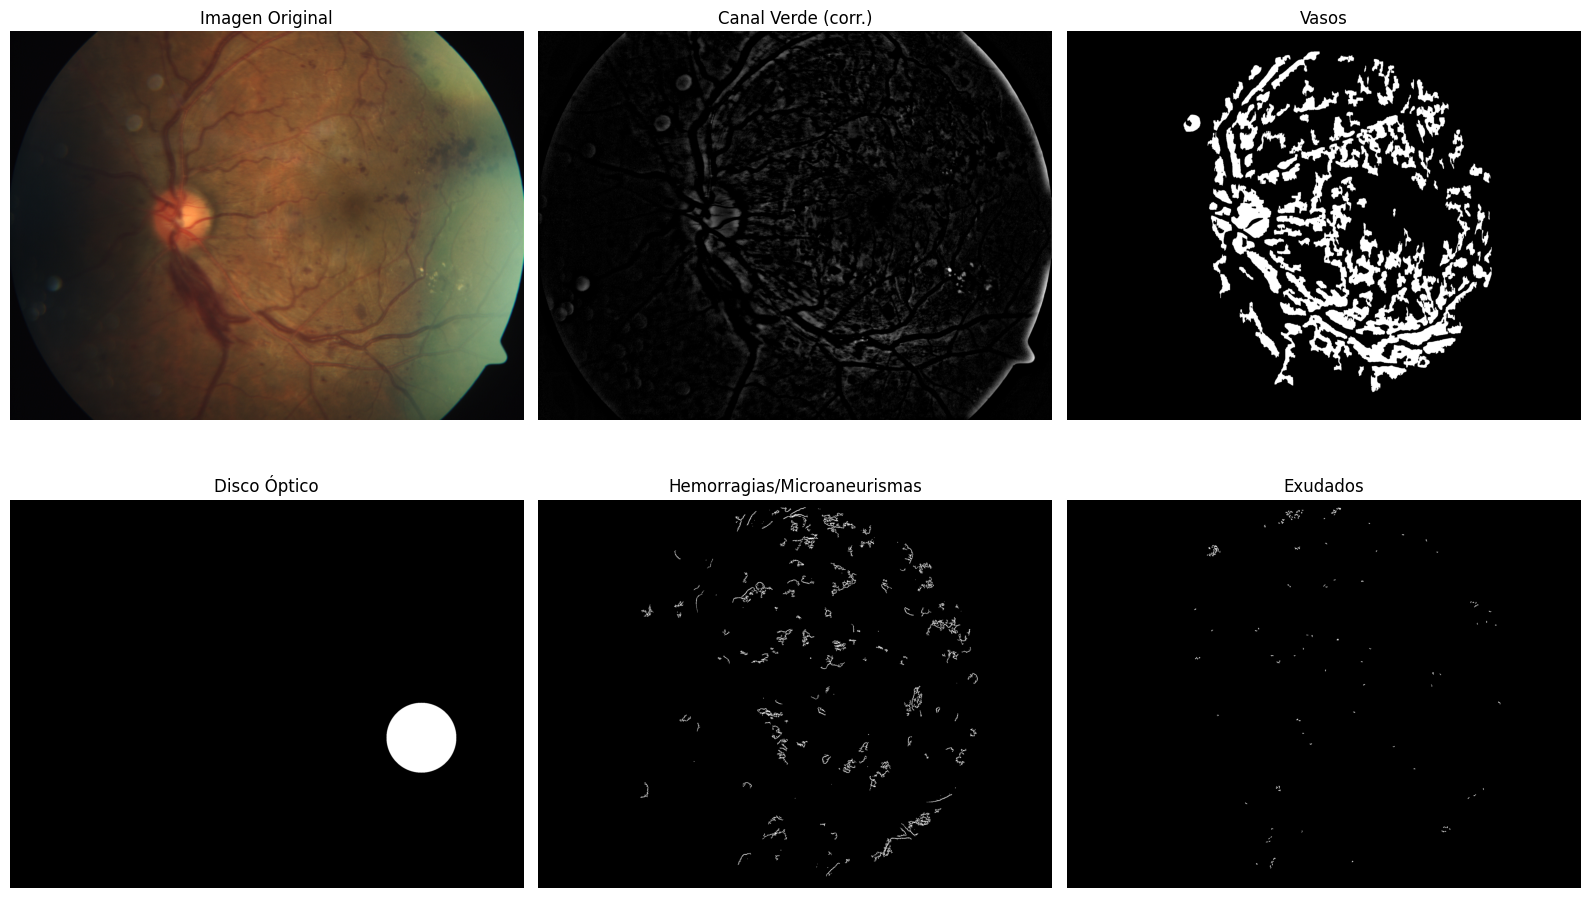

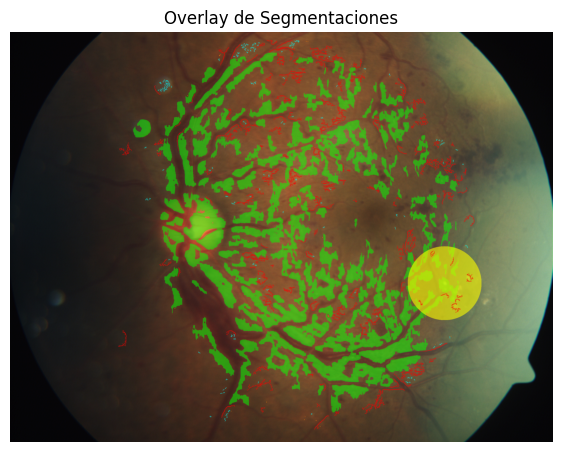

In [23]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, pandas as pd

DATASETS = {
    "aptos": {
        "img_dir": r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train",
        "csv":     r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\aptos_2019\train.csv",
        "exts":    (".jpeg", ".jpg", ".png"),
        "preset": {
            "remove_scars": True,   
            "ring_exclude": True,

            # Vasos
            "vessels_zsigma": 1.25,
            "vessels_min_area": 150,
            "vessels_min_elong": 3.2,
            "vessels_ecc_min": 6.0,           # nueva: alargamiento mínimo (lambda1/lambda2)
            "vessels_keep_if_area": 1200,     # nueva: si el blob es grande, lo dejamos aunque sea poco alargado
            "vessels_round_cut_area": 900,
            "vessel_excl_thin": 5,

            # Lesiones oscuras
            "vessel_excl_dilate": 15,
            "od_excl_dilate": 24,
            "contrast_delta": 12,
            "ma_area": (5, 140),
            "ma_max_ar": 1.75,
            "ma_min_circ": 0.56,    
            "hemo_area": (80, 4000),
            "hemo_max_ar": 3.2,
            "dark_kz": 0.35,           # bajar z-score → más detecciones
            "dark_win": 9, 

            # Exudados
            "tophat_white": 55,
            "exu_percentile": 96.5,
            "exu_area": (25, 6000),
            "exu_rings": 8, 
        }
    },

}

# -------- helpers mínimos --------
def resolve_filename(img_id: str, base_dir: str, exts=(".png",".jpg",".jpeg")) -> str:
    if img_id.lower().endswith(('.png','.jpg','.jpeg')): return img_id
    for ext in exts:
        p = os.path.join(base_dir, img_id + ext)
        if os.path.exists(p): return img_id + ext
    return img_id + exts[0]

def comp_metrics_from_bbox(w, h): return max(w, h) / (min(w, h) + 1e-6)

def circ_score(cnt):
    """Circularidad a partir de un contorno (0..1)."""
    a = cv2.contourArea(cnt)
    p = cv2.arcLength(cnt, True)
    return 0.0 if p <= 0 or a <= 0 else float(4*np.pi*a/(p*p))

def contour_circularity(mask):
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return 0.0
    c = max(cnts, key=cv2.contourArea)
    a = cv2.contourArea(c); p = cv2.arcLength(c, True)
    return 0.0 if p<=0 or a<=0 else float(4*np.pi*a/(p*p))

def gabor_bank_enhance(img_gray, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45, psi=0):
    thetas = np.deg2rad(np.arange(0, 180, 15))
    acc = np.zeros_like(img_gray, dtype=np.float32)
    for th in thetas:
        k = cv2.getGaborKernel((ksize, ksize), sigma, th, lambd, gamma, psi, ktype=cv2.CV_32F)
        acc = np.maximum(acc, cv2.filter2D(img_gray, cv2.CV_32F, k))
    return cv2.normalize(acc, None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

# -------- pipeline único --------
def run_pipeline(image_path, P):
    img_bgr = cv2.imread(image_path); assert img_bgr is not None, image_path
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H,W = img.shape[:2]
    yy, xx = np.mgrid[0:H,0:W]; cy, cx = H//2, W//2; r = int(min(H,W)*0.48)
    fov_mask = (((yy-cy)**2 + (xx-cx)**2) <= r*r).astype(np.uint8)*255

    ring_mask = np.zeros_like(fov_mask)
    if P.get("ring_exclude", True):
        dist2 = (yy-cy)**2 + (xx-cx)**2
        ring_mask = ((dist2 > (0.93*r)**2) & (dist2 <= r*r)).astype(np.uint8)*255

    g = img[:,:,1]
    g_eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(g)
    bg = cv2.GaussianBlur(g_eq, (0,0), sigmaX=25, sigmaY=25)
    g_corr = cv2.normalize(cv2.subtract(g_eq,bg), None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

    # scars opcional
    if P.get("remove_scars", False):
        g_blur = cv2.GaussianBlur(g_eq, (0,0), 1.5)
        circles = cv2.HoughCircles(g_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=18,
                                   param1=80, param2=18, minRadius=6, maxRadius=28)
        scars_mask = np.zeros_like(g, np.uint8)
        if circles is not None:
            circles = np.uint16(np.around(circles[0]))
            for x,y,rad in circles: cv2.circle(scars_mask,(x,y), int(rad*1.1), 255, -1)
        scars_mask = cv2.dilate(scars_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), 1)
    else:
        scars_mask = np.zeros_like(g, np.uint8)

    # --- vasos
    v_big = gabor_bank_enhance(g_corr, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45)
    v_sm  = gabor_bank_enhance(g_corr, ksize=21, sigma=3.2, lambd=9.0,  gamma=0.45)
    v_tmp = cv2.max(v_big, v_sm)                 # realce final
    v_tmp[(fov_mask==0) | (ring_mask>0)] = 0     # fuera de FOV/anillo no cuenta

    # Umbral "duro" + Otsu
    mu, sd = cv2.meanStdDev(v_tmp, mask=fov_mask)[0][0], cv2.meanStdDev(v_tmp, mask=fov_mask)[1][0]
    hard = (v_tmp > (mu + P["vessels_zsigma"]*sd)).astype(np.uint8)*255
    _, v_otsu = cv2.threshold(v_tmp, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    v_bin = cv2.bitwise_and(hard, v_otsu)

    # Histeresis por percentiles (conectar trazos finos)
    vals = v_tmp[v_tmp>0]
    hi = max(30, int(np.percentile(vals, 92))) if vals.size else 60
    lo = max(5,  int(0.45*hi))
    strong = (v_tmp >= hi).astype(np.uint8)*255
    weak   = ((v_tmp >= lo) & (v_tmp < hi)).astype(np.uint8)*255
    kernel8 = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
    grow = strong.copy()
    for _ in range(4):
        grow = cv2.dilate(grow, kernel8, 1)
        weak[grow>0] = 255
    v_bin = cv2.bitwise_or(v_bin, weak)

        # Limpiezas
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_RECT,(1,11)), 1)
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(1,5)), 1)
    kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    v_bin = cv2.dilate(cv2.erode(v_bin, kernel3, 1), kernel3, 1)

    # Filtrado por componentes conectados
    num, lab, stats, _ = cv2.connectedComponentsWithStats(v_bin, 8)
    clean_vessels = np.zeros_like(v_bin)

    muV, sdV = cv2.meanStdDev(v_tmp, mask=fov_mask)
    muV, sdV = float(muV), float(sdV)

    for i in range(1, num):
        x,y,w,h,area = stats[i]
        if area < P["vessels_min_area"]:
            continue

        # respuesta media en el realce
        resp_mean = float(v_tmp[lab==i].mean())
        if resp_mean < (muV + 0.6*sdV):     
            continue

        # alargamiento mediante PCA
        ys, xs = np.where(lab==i)
        X  = np.column_stack((xs, ys)).astype(np.float32)
        Xc = X - X.mean(0, keepdims=True)
        C  = (Xc.T @ Xc) / max(1, Xc.shape[0]-1)
        evals, _ = np.linalg.eigh(C)
        lam1, lam2 = float(evals.max()), float(evals.min()+1e-6)
        ecc = lam1/lam2

        # Criterio final: muy alargado o suficientemente grande
        if (ecc >= P["vessels_ecc_min"]) or (area >= P["vessels_keep_if_area"]):
            clean_vessels[lab==i] = 255

    clean_vessels[fov_mask==0] = 0





    # --- disco óptico (SECCIÓN CORREGIDA) ---
    r_ch, g_ch, b_ch = img[:,:,0], img[:,:,1], img[:,:,2]
    comb = cv2.addWeighted(cv2.addWeighted(b_ch, 0.3, g_ch, 0.45, 0), 1.0, r_ch, 0.25, 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    comb_eq = clahe.apply(comb)
    comb_blur = cv2.GaussianBlur(comb_eq, (51,51), 0)

    # --- Prior vascular y score base ---
    vess_dens = cv2.GaussianBlur(((clean_vessels > 0).astype(np.uint8) * 255), (41, 41), 0)
    vess_dens = cv2.normalize(vess_dens, None, 0, 255, cv2.NORM_MINMAX)
    score = cv2.addWeighted(comb_blur, 0.3, vess_dens, 0.7, 0)  # mapa de probabilidad base

    # --- Estimar lado de forma robusta (anillo lateral) ---
    H, W = g.shape
    yy, xx = np.mgrid[0:H, 0:W]
    cy, cx = H // 2, W // 2
    r_fov = int(0.48 * min(H, W))

    dist2 = (yy - cy)**2 + (xx - cx)**2
    ring = (dist2 > (0.55 * r_fov)**2) & (dist2 < (0.95 * r_fov)**2) & (fov_mask > 0)

    # normaliza a [0,1] para combinar
    sb = cv2.normalize(comb_blur, None, 0, 1, cv2.NORM_MINMAX).astype(np.float32)
    sv = cv2.normalize(vess_dens, None, 0, 1, cv2.NORM_MINMAX).astype(np.float32)

    side_map = 0.35 * sb + 0.65 * sv
    S_left  = side_map[ring & (xx <  cx)].mean() if (ring & (xx <  cx)).any() else 0.0
    S_right = side_map[ring & (xx >= cx)].mean() if (ring & (xx >= cx)).any() else 0.0
    disc_on_left = S_left > S_right

    # --- Sesgo lateral suave (gradiente) ---
    if disc_on_left:
        weights = np.linspace(1.0, 0.6, W, dtype=np.float32)   # favorece izquierda
    else:
        weights = np.linspace(0.6, 1.0, W, dtype=np.float32)   # favorece derecha
    lateral_bias = np.tile(weights, (H, 1))
    score = (score.astype(np.float32) * lateral_bias).astype(np.uint8)

    # seguridad: fuera del FOV/anillo de borde -> 0
    score[fov_mask == 0] = 0
    if 'ring_mask' in locals():
        score[ring_mask > 0] = 0
    
    
    # Generación de candidatos (modificada para buscar en toda el área)
    final_optic_disc = np.zeros_like(g, np.uint8)
    fov_area = int((fov_mask>0).sum())
    best, best_score = None, -1.0
    
    # Búsqueda sobre el mapa de puntuación con sesgo
    for p in [94, 96, 97, 98, 99]:
        # Ya no necesitamos una máscara de zona válida, el sesgo está en 'score'
        thr = np.percentile(score[score>0], p) if (score>0).any() else 255
        _, m = cv2.threshold(score, thr, 255, cv2.THRESH_BINARY)
        
        kL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17,17))
        m  = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kL)
        m  = cv2.morphologyEx(m, cv2.MORPH_OPEN,  kL)
        m[fov_mask==0] = 0 # Aseguramos que solo buscamos dentro del FOV

        cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            area = cv2.contourArea(c)
            if not (0.006*fov_area < area < 0.06*fov_area):
                continue

                # --- Filtro por mitad esperada (según disc_on_left) ---
            M = cv2.moments(c)
            if M['m00'] == 0:
                continue
            x_bar = M['m10'] / M['m00']   # centroide en x del contorno

            margin = 0.05 * W             # 5% de margen para no ser demasiado estricto
            if disc_on_left and x_bar > (cx + margin):
                continue
            if (not disc_on_left) and x_bar < (cx - margin):
                continue

            
            per  = cv2.arcLength(c, True)
            circ = 4*np.pi*area/(per*per + 1e-6)
            if circ < 0.45:
                continue

            mask_c = np.zeros_like(g, np.uint8); cv2.drawContours(mask_c, [c], -1, 255, -1)
            sc_bright = float(comb_blur[mask_c>0].mean())
            sc_vdens  = float(vess_dens[mask_c>0].mean())
            # La puntuación final del candidato no incluye el sesgo para ser objetiva
            score_c   = 0.2*sc_bright + 0.7*sc_vdens + 0.1*(circ*255)

            if score_c > best_score:
                best_score, best = score_c, c

    rad = 0 # Inicializar rad para el bloque de fallback
    if best is not None:
        A = cv2.contourArea(best)
        # radio equivalente por área (más estable que minEnclosingCircle si el contorno quedó cortado)
        rad_eq = int(np.sqrt(A/np.pi))
        # ampliar un poco y acotar a un rango razonable
        rad = int(np.clip(1.10*rad_eq, 0.0085*min(H,W), 0.16*min(H,W)))
        (cx_od, cy_od), _ = cv2.minEnclosingCircle(best)
        cv2.circle(final_optic_disc, (int(cx_od), int(cy_od)), rad, 255, -1)

        A = cv2.contourArea(best)
        
    else:
        # Fallback: buscar el punto más brillante en el mapa de puntuación con sesgo
        if (score > 0).any():
            _, _, _, max_loc = cv2.minMaxLoc(score, mask=fov_mask)
            cx_od, cy_od = max_loc
            rad = int(0.09 * min(H, W))
            cv2.circle(final_optic_disc, (cx_od, cy_od), rad, 255, -1)

            # --- Verificación de lado: si quedó en el lado "equivocado", reubicar en la mitad esperada
            half_mask = np.zeros_like(fov_mask, np.uint8)
            if disc_on_left:
                half_mask[:, :cx] = 255
            else:
                half_mask[:, cx:] = 255

            if ('cx_od' in locals()) and (((cx_od < cx) != disc_on_left)):  # está en el lado contrario
                # toma el máximo del 'score' en la mitad esperada
                _, _, _, max_loc = cv2.minMaxLoc(score, mask=cv2.bitwise_and(fov_mask, half_mask))
                cx_od, cy_od = max_loc

    # después de dibujar final_optic_disc
    od_rad_val = rad if rad > 0 else int(0.09 * min(H, W))
    od_rad = max(5, int(0.55 * od_rad_val))
    excl   = cv2.dilate(final_optic_disc, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*od_rad+1,)*2), 1)




    # exclusiones
    vessel_excl = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["vessel_excl_dilate"],)*2),1)
    excl       = cv2.dilate(final_optic_disc, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["od_excl_dilate"],)*2),1)

    vessel_excl_thin = cv2.dilate(clean_vessels,
                              cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                                        (P.get("vessel_excl_thin",7),)*2), 1)
    mask_valid = (fov_mask>0) & (excl==0) & (vessel_excl_thin==0)

    # --- oscuras
    bh_s = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)))
    bh_m = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15)))
    bh   = cv2.max(bh_s, bh_m)
    bh[(fov_mask==0)|(ring_mask>0)|(vessel_excl==255)|(excl==255)|(scars_mask>0)] = 0

    dog = cv2.GaussianBlur(g_corr,(0,0),1.0) - cv2.GaussianBlur(g_corr,(0,0),2.0)
    dog = cv2.normalize(dog,None,0,255,cv2.NORM_MINMAX).astype(np.uint8); dog[fov_mask==0]=0
    cand = cv2.addWeighted(bh,0.7,dog,0.3,0)
    _, dark_bin = cv2.threshold(cand, 0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    dark_bin = cv2.medianBlur(dark_bin,3)
    dark_bin = cv2.morphologyEx(dark_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)
    near_vess = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)), 1)
    dark_bin[near_vess==255] = 0

    # Requisito de "valle" local (z-score): el píxel lesionado debe estar < media - k*std
    k_z  = P.get("dark_kz", 0.6)
    win  = P.get("dark_win", 11)
    mu   = cv2.boxFilter(g_corr, ddepth=-1, ksize=(win,win))
    sq   = cv2.boxFilter((g_corr.astype(np.float32)**2), ddepth=-1, ksize=(win,win))
    std  = cv2.sqrt(np.maximum(1e-6, sq - mu**2))
    zmap = (mu - g_corr.astype(np.float32)) / (std + 1e-6)
    dark_bin[(zmap < k_z)] = 0


    num, lab, stats, cents = cv2.connectedComponentsWithStats(dark_bin, 8)
    micro_mask = np.zeros_like(dark_bin); hemo_mask = np.zeros_like(dark_bin)
    for i in range(1,num):
        x,y,w,h,area = stats[i]
        if not (3 <= area <= 2500): continue
        cx,cy = int(cents[i][0]), int(cents[i][1])
        y1,y2=max(0,cy-10),min(H,cy+10); x1,x2=max(0,cx-10),min(W,cx+10)
        roi = g_corr[y1:y2,x1:x2]; mroi = (lab[y1:y2,x1:x2]==i)
        if mroi.sum()==0: continue
        lesion = roi[mroi].mean(); back = roi[~mroi].mean() if (~mroi).sum()>0 else lesion+1
        if lesion >= back - P["contrast_delta"]: continue
        ar = comp_metrics_from_bbox(w,h)
        cmask = (lab==i).astype(np.uint8)*255; circ = contour_circularity(cmask)
        if P["ma_area"][0] <= area <= P["ma_area"][1] and ar <= P["ma_max_ar"] and circ >= P["ma_min_circ"]:
            micro_mask[lab==i]=255
        elif P["hemo_area"][0] < area <= P["hemo_area"][1] and ar <= P["hemo_max_ar"]:
            hemo_mask[lab==i]=255

    # --- exudados
    wh = cv2.morphologyEx(g_corr, cv2.MORPH_TOPHAT,
                        cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["tophat_white"],)*2))
    mask_valid = (fov_mask>0) & (excl==0) & (vessel_excl==0)  # y sin scars si los usas

    wh = cv2.morphologyEx(
    g_corr, cv2.MORPH_TOPHAT,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["tophat_white"],)*2)
    )
    # DoG brillante (realza puntos/blobs claros)
    dog_w = cv2.GaussianBlur(g_corr,(0,0),1.0) - cv2.GaussianBlur(g_corr,(0,0),2.5)
    dog_w = cv2.normalize(dog_w, None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

    wh = cv2.addWeighted(wh, 0.7, dog_w, 0.3, 0)

    mask_valid = (fov_mask>0) & (excl==0) & (vessel_excl==0) & (scars_mask==0)

    # Umbral ADAPTATIVO por anillos (compensa iluminación radial)
    exu = np.zeros_like(wh, np.uint8)
    cy, cx = np.array(wh.shape)//2
    yy, xx = np.mgrid[0:wh.shape[0], 0:wh.shape[1]]
    rr = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    rmax = rr[mask_valid].max() if mask_valid.any() else rr.max()

    n_rings = P.get("exu_rings", 6)
    edges = np.linspace(0, rmax, n_rings+1)
    for i in range(n_rings):
        ring = (rr>=edges[i]) & (rr<edges[i+1]) & mask_valid
        if ring.sum()<100: continue
        p = np.percentile(wh[ring], P["exu_percentile"])
        ring_bin = (wh>=p).astype(np.uint8)*255
        exu[ring] = ring_bin[ring]

    exudates = cv2.medianBlur(exu, 3)
    exudates = cv2.morphologyEx(exudates, cv2.MORPH_OPEN,
                                cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)

    # Filtrado por área + circularidad (quita scars redondos si aparecieran)
    num, lab, stats, _ = cv2.connectedComponentsWithStats(exudates, 8)
    exu_clean = np.zeros_like(exudates)
    for i in range(1, num):
        A = stats[i, cv2.CC_STAT_AREA]
        if P["exu_area"][0] <= A <= P["exu_area"][1]:
            cmask = (lab==i).astype(np.uint8)*255
            circ  = contour_circularity(cmask)
            if circ > 0.65 and A < 1200:   # muy redondos y chicos → probable “scar”
                continue
            exu_clean[lab==i] = 255
    exudates = exu_clean

    # ----- visualización (opcional) -----
    plt.figure(figsize=(16,10))
    plt.subplot(2,3,1); plt.imshow(img);                 plt.title("Imagen Original"); plt.axis('off')
    plt.subplot(2,3,2); plt.imshow(g_corr, cmap='gray'); plt.title("Canal Verde (corr.)"); plt.axis('off')
    plt.subplot(2,3,3); plt.imshow(clean_vessels, cmap='gray'); plt.title("Vasos"); plt.axis('off')
    plt.subplot(2,3,4); plt.imshow(final_optic_disc, cmap='gray'); plt.title("Disco Óptico"); plt.axis('off')
    plt.subplot(2,3,5); plt.imshow(cv2.bitwise_or(micro_mask, hemo_mask), cmap='gray'); plt.title("Hemorragias/Microaneurismas"); plt.axis('off')
    plt.subplot(2,3,6); plt.imshow(exudates, cmap='gray'); plt.title("Exudados"); plt.axis('off')
    plt.tight_layout(); plt.show()

    overlay = img.copy()
    def paint(mask, color, alpha=0.6):
        c = np.zeros_like(img); c[:] = color
        m3 = np.dstack([mask]*3)
        return np.where(m3>0, (alpha*c + (1-alpha)*overlay).astype(np.uint8), overlay)
    overlay = paint(clean_vessels,(0,255,0),0.5)
    overlay = paint(final_optic_disc,(255,255,0),0.6)
    overlay = paint(hemo_mask,(255,0,0),0.7)
    overlay = paint(micro_mask,(255,128,0),0.7)
    overlay = paint(exudates,(0,255,255),0.6)

    plt.figure(figsize=(7,7)); plt.imshow(overlay); plt.title("Overlay de Segmentaciones"); plt.axis('off'); plt.show()

    fov_pixels = max(1, int(fov_mask.sum()/255))
    metrics = {
        "vessel_px": int((clean_vessels>0).sum()),
        "vessel_%FOV": round(100*(clean_vessels>0).sum()/fov_pixels, 2),
        "MA_px": int((micro_mask>0).sum()),
        "Hemo_px": int((hemo_mask>0).sum()),
        "Exud_px": int((exudates>0).sum()),
    }
    return {"overlay": overlay, "metrics": metrics}

# -------- selector genérico: mismo código para ambos datasets --------
def pick_and_run(dataset="aptos", level=2, seed=42, force_image_id=None):
    cfg = DATASETS[dataset]
    df = pd.read_csv(cfg["csv"])                 # ¡ya tienes image/level!
    assert {'image','level'}.issubset(df.columns)
    df_lvl = df[df['level']==level].copy()
    assert not df_lvl.empty, f"No hay nivel {level} en {dataset}."

    if force_image_id:
        row = df_lvl[df_lvl['image'].astype(str)==str(force_image_id)]
        if row.empty:
            base = os.path.splitext(str(force_image_id))[0]
            row = df_lvl[df_lvl['image'].astype(str)==base]
        if row.empty:
            raise ValueError(f"{force_image_id} no está en el CSV con nivel {level}.")
        img_id = str(row.iloc[0]['image'])
    else:
        img_id = str(df_lvl.sample(1, random_state=seed).iloc[0]['image'])

    image_name = resolve_filename(img_id, cfg["img_dir"], exts=cfg["exts"])
    image_path = os.path.join(cfg["img_dir"], image_name)
    print(f"[{dataset}] nivel {level} -> {image_name}")
    return run_pipeline(image_path, cfg["preset"])


res = pick_and_run(dataset="aptos", level=4, seed=42)